# 03 — Adjusted associations with outer bootstrap and MICE imputation

**Purpose:** estimate adjusted associations between iron supplementation and haematological / inflammatory biomarkers in Brazilian infants 6–24 months, with outer-bootstrap inference (B = 2000) and MICE imputation of missing covariates within each bootstrap sample.

**Components produced in this notebook:**
1. Adjusted Poisson (binary) and OLS (continuous) regression of each outcome on iron exposure plus 26 confounders, with HC1 robust standard errors. Analytical 95% CIs reported.
2. Outer bootstrap with B = 2000 reps; MICE imputation (single iteration per bootstrap sample) is applied to covariates with missing values. Bootstrap 95% CIs reported alongside analytical ones.
3. Benjamini–Hochberg false-discovery-rate adjustment across the seven primary outcomes.
4. Sensitivity analysis comparing infants exposed to iron alone (no co-supplementation) versus infants who received no supplement at all, motivated by the substantial co-supplementation imbalance documented in Stage 1.
5. Iron × breastfeeding interaction tests for the four central continuous outcomes (Hb, ferritin, haematocrit, MCV), pre-specified to evaluate the lactoferrin hypothesis described in `NARRATIVE.md`.
6. Forest plots and CSV/markdown report compiled to `03_adjusted_associations_results/` on each execution.

**Decisions documented in `Manuscript/methods.md` and `NARRATIVE.md`:**
- Outer bootstrap B = 2000; MICE for missing covariates only (not outcomes); complete-case for outcomes (NaN preserved).
- Survey weights are **not** used at this stage to keep the inferential pipeline focused; a survey-weighted sensitivity is deferred to a later notebook.
- All language follows the non-causal, non-predictive rule from NARRATIVE.md.

In [1]:
import warnings
import time
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA_PATH = Path('../Data/data_crianca_calib_anon.csv')
RNG = np.random.default_rng(42)
B = 2000
Z95 = 1.959964
print(f'Configuration: B = {B}, MICE-imputed covariates within bootstrap, HC1 analytical CIs.')

Configuration: B = 2000, MICE-imputed covariates within bootstrap, HC1 analytical CIs.


## 1. Data and variable construction

Same construction as Notebook 02. Confounders are listed explicitly so the model formulas downstream are transparent.

In [2]:
raw = pd.read_csv(DATA_PATH, low_memory=False)
raw['age_months'] = raw['b05a_idade_em_meses'].astype(str).str.extract(r'(\d+)').astype(float)
df = raw[(raw['age_months'] >= 6) & (raw['age_months'] <= 24)].copy()

df['iron_any'] = (df['vd_supl1_com_ferro'] == 'Sim').astype(int)
df['iron_only'] = (df['vd_supl1_exclusivamente_ferro'] == 'Sim').astype(int) if 'vd_supl1_exclusivamente_ferro' in df.columns else 0
df['no_supplement'] = ((df['iron_any'] == 0) & (df['vd_num_supl'].astype(str).str.extract(r'(\d+)')[0].astype(float).fillna(0) == 0)).astype(int)

df['male'] = (df['b02_sexo'] == 'Masculino').astype(int)
df['race_preta'] = (df['d01_cor'] == 'Preta').astype(int)
df['race_parda'] = df['d01_cor'].isin(['Parda (mulata, cabocla, cafuza, mameluca ou mestiça)', 'Parda']).astype(int)
df['reg_norte'] = (df['a00_regiao'] == 'Norte').astype(int)
df['reg_nordeste'] = (df['a00_regiao'] == 'Nordeste').astype(int)
df['reg_sul'] = (df['a00_regiao'] == 'Sul').astype(int)
df['reg_co'] = (df['a00_regiao'] == 'Centro-Oeste').astype(int)
df['urban'] = (df['a11_situacao'] == 'Urbano').astype(int)
df['ien'] = pd.to_numeric(df['vd_ien_quintos'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
df['ebia_leve'] = (df['vd_ebia_categ'] == 'Insegurança leve').astype(int)
df['ebia_mod'] = (df['vd_ebia_categ'] == 'Insegurança moderada').astype(int)
df['ebia_grave'] = (df['vd_ebia_categ'] == 'Insegurança grave').astype(int)
df['esgoto_adeq'] = df['p10_esgoto'].isin([
    'Rede geral de esgoto ou pluvial', 'Fossa séptica ligada a rede', 'Fossa séptica não ligada a rede',
]).astype(int)
df['agua_rede'] = (df['p11_agua'] == 'Rede geral de distribuição').astype(int)
df['cesarean'] = df['h04_parto'].isin(['Cesariana agendada (eletiva)', 'Cesariana de urgência (não agendada)']).astype(int)
df['gest_weeks'] = pd.to_numeric(df['h01_semanas_gravidez'], errors='coerce')
df['birth_weight'] = pd.to_numeric(df['h02_peso'], errors='coerce')
df['prenatal_visits'] = pd.to_numeric(df['k05_prenatal_consultas'], errors='coerce')
df['maternal_age'] = pd.to_numeric(df['bb04_idade_da_mae'], errors='coerce')
df['breastfed'] = (df['e01_leite_peito'] == 'Sim').astype(int)
df['formula'] = (df['e10_formula_infantil'] == 'Sim').astype(int)
df['cow_milk'] = ((df['e06_leite_vaca_po'] == 'Sim') | (df['e07_leite_vaca_liquido'] == 'Sim')).astype(int)
import re
def _educ_band(text):
    if pd.isna(text):
        return 'Unknown'
    t = str(text)
    if 'Sem estudo' in t:
        return 'Less than primary'
    if 'fundamental' in t.lower():
        m = re.search(r'(\d+)', t)
        if m and int(m.group(1)) >= 8:
            return 'Primary completed'
        return 'Less than primary'
    if 'ensino médio' in t.lower():
        if '3°ano' in t or '3° ano' in t:
            return 'Secondary completed'
        return 'Primary completed'
    if 'superior' in t.lower():
        return 'Tertiary or above'
    return 'Unknown'
df['_education_band'] = df['j10_serie'].apply(_educ_band)
df['educ_primary'] = (df['_education_band'] == 'Primary completed').astype(int)
df['educ_secondary'] = (df['_education_band'] == 'Secondary completed').astype(int)
df['educ_tertiary'] = (df['_education_band'] == 'Tertiary or above').astype(int)


df['hb'] = pd.to_numeric(df['vd_hb_final'], errors='coerce')
df['ferritin'] = pd.to_numeric(df['vd_ferri_final'], errors='coerce')
df['haematocrit'] = pd.to_numeric(df['vd_ht_final'], errors='coerce')
df['mcv'] = pd.to_numeric(df['vd_vcm_final'], errors='coerce')
df['mch'] = pd.to_numeric(df['vd_hcm_final'], errors='coerce')
df['mchc'] = pd.to_numeric(df['vd_chcm_final'], errors='coerce')
df['rdw'] = pd.to_numeric(df['vd_rdw_final'], errors='coerce')
df['crp'] = pd.to_numeric(df['vd_pcr_final'], errors='coerce')

def to_binary_with_nan(series, threshold, comparator='lt'):
    cond = series < threshold if comparator == 'lt' else series > threshold
    return cond.where(series.notna(), other=pd.NA).astype('Int64')

df['anaemia'] = to_binary_with_nan(df['hb'], 10.5, 'lt')
df['iron_deficiency'] = to_binary_with_nan(df['ferritin'], 12, 'lt')
df['crp_elevated'] = to_binary_with_nan(df['crp'], 5, 'gt')

CONFOUNDERS = [
    'age_months', 'male', 'race_preta', 'race_parda',
    'reg_norte', 'reg_nordeste', 'reg_sul', 'reg_co', 'urban',
    'ien', 'ebia_leve', 'ebia_mod', 'ebia_grave',
    'esgoto_adeq', 'agua_rede', 'cesarean',
    'gest_weeks', 'birth_weight', 'prenatal_visits', 'maternal_age',
    'breastfed', 'formula', 'cow_milk',
    'educ_primary', 'educ_secondary', 'educ_tertiary',
]
MISSING_PRONE_COVARIATES = ['gest_weeks', 'birth_weight', 'prenatal_visits', 'maternal_age', 'ien']
PRIMARY_CONTINUOUS = ['hb', 'ferritin', 'haematocrit', 'mcv']
SECONDARY_CONTINUOUS = ['mch', 'mchc', 'rdw', 'crp']
BINARY_OUTCOMES = ['anaemia', 'iron_deficiency', 'crp_elevated']

OUTCOME_LABELS = {
    'hb': 'Haemoglobin (g/dL)',
    'ferritin': 'Ferritin (ng/mL)',
    'haematocrit': 'Haematocrit (%)',
    'mcv': 'MCV (fL)',
    'mch': 'MCH (pg)',
    'mchc': 'MCHC (g/dL)',
    'rdw': 'RDW (%)',
    'crp': 'C-reactive protein (mg/L)',
    'anaemia': 'Anaemia (Hb < 10.5)',
    'iron_deficiency': 'Iron deficiency (ferritin < 12)',
    'crp_elevated': 'Elevated CRP (> 5 mg/L)',
}

print(f'Analytic sample (6–24 mo): {len(df):,}')
print(f'Iron-exposed: {int(df.iron_any.sum()):,} ({df.iron_any.mean()*100:.1f}%)')
print(f'Iron-only: {int(df.iron_only.sum()):,}')
print(f'No supplement at all: {int(df.no_supplement.sum()):,}')
print(f'Confounders: {len(CONFOUNDERS)}')
print(f'Missing-prone covariates (will be MICE-imputed): {MISSING_PRONE_COVARIATES}')

Analytic sample (6–24 mo): 4,601
Iron-exposed: 1,353 (29.4%)
Iron-only: 353
No supplement at all: 1,637
Confounders: 26
Missing-prone covariates (will be MICE-imputed): ['gest_weeks', 'birth_weight', 'prenatal_visits', 'maternal_age', 'ien']


## 2. Missing data overview

Tabulates missingness in each confounder and biomarker. Justifies the choice of MICE for covariates and complete-case for outcomes.

In [3]:
missing_rows = []
for var in CONFOUNDERS:
    n_missing = int(df[var].isna().sum())
    missing_rows.append({
        'Variable': var,
        'Type': 'Confounder',
        'N missing': n_missing,
        'Pct missing': f'{n_missing / len(df) * 100:.2f}%',
    })
for var in PRIMARY_CONTINUOUS + SECONDARY_CONTINUOUS + BINARY_OUTCOMES:
    n_missing = int(df[var].isna().sum())
    missing_rows.append({
        'Variable': var,
        'Type': 'Outcome',
        'N missing': n_missing,
        'Pct missing': f'{n_missing / len(df) * 100:.2f}%',
    })
missing_table = pd.DataFrame(missing_rows).set_index('Variable')
missing_table

,Type,N missing,Pct missing
Variable,,,
age_months,Confounder,0,0.00%
male,Confounder,0,0.00%
race_preta,Confounder,0,0.00%
race_parda,Confounder,0,0.00%
reg_norte,Confounder,0,0.00%
reg_nordeste,Confounder,0,0.00%
reg_sul,Confounder,0,0.00%
reg_co,Confounder,0,0.00%
urban,Confounder,0,0.00%


## 3. Helper functions

- `mice_impute_covariates`: applies sklearn's IterativeImputer (a MICE-equivalent algorithm) to the missing-prone covariates, leaving fully observed variables untouched.
- `fit_continuous` / `fit_binary`: adjusted OLS / Poisson with HC1 robust SE, returning the coefficient on the exposure.
- `bh_fdr`: Benjamini–Hochberg adjusted q-values.

In [4]:
def mice_impute_covariates(df_in, vars_to_impute=MISSING_PRONE_COVARIATES, max_iter=10, random_state=None):
    df_out = df_in.copy()
    needed = [v for v in vars_to_impute if df_out[v].isna().any()]
    if not needed:
        return df_out
    aux_features = [v for v in CONFOUNDERS if v not in vars_to_impute and df_out[v].isna().sum() == 0]
    matrix = df_out[needed + aux_features].astype(float)
    imp = IterativeImputer(estimator=BayesianRidge(), max_iter=max_iter, random_state=random_state, sample_posterior=False)
    imputed = imp.fit_transform(matrix)
    df_out[needed] = imputed[:, : len(needed)]
    return df_out

def fit_continuous(df_in, outcome, exposure='iron_any', extra=()):
    sub = df_in[[outcome, exposure] + list(extra) + CONFOUNDERS].dropna(subset=[outcome, exposure])
    if len(sub) < 100:
        return None
    rhs = exposure + (' + ' + ' + '.join(extra) if extra else '') + ' + ' + ' + '.join(CONFOUNDERS)
    model = smf.ols(f'{outcome} ~ {rhs}', data=sub).fit(cov_type='HC1')
    return model

def fit_binary(df_in, outcome, exposure='iron_any', extra=()):
    sub = df_in[[outcome, exposure] + list(extra) + CONFOUNDERS].dropna(subset=[outcome, exposure])
    sub[outcome] = sub[outcome].astype(int)
    if sub[outcome].sum() < 5 or len(sub) < 100:
        return None
    rhs = exposure + (' + ' + ' + '.join(extra) if extra else '') + ' + ' + ' + '.join(CONFOUNDERS)
    try:
        model = smf.glm(f'{outcome} ~ {rhs}', data=sub, family=sm.families.Poisson()).fit(cov_type='HC1', disp=False)
    except Exception:
        return None
    return model

def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    m = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * m / (np.arange(m) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(m)
    out[order] = np.minimum(q, 1.0)
    return out

def boot_pvalue(coefs, null=0.0):
    arr = np.asarray(coefs)
    p_lo = float(np.mean(arr <= null))
    p_hi = float(np.mean(arr >= null))
    return float(min(1.0, 2 * min(p_lo, p_hi)))

def coef_from(model, term):
    if model is None or term not in model.params.index:
        return None
    return float(model.params[term])

print('Helpers ready.')

Helpers ready.


## 4. Primary adjusted analysis (analytical CIs)

Single fit per outcome with HC1 robust SE, on the complete-case sample for that outcome (NaN biomarkers excluded). Covariate missingness is handled by MICE imputation **once** for analytical estimation, then carried through bootstrap separately for inference.

In [5]:
df_imputed = mice_impute_covariates(df, random_state=42)

primary_rows = []
for outcome in PRIMARY_CONTINUOUS + SECONDARY_CONTINUOUS:
    m = fit_continuous(df_imputed, outcome)
    if m is None:
        continue
    coef = float(m.params['iron_any'])
    se = float(m.bse['iron_any'])
    p = float(m.pvalues['iron_any'])
    primary_rows.append({
        'Outcome': OUTCOME_LABELS[outcome], 'Type': 'continuous', 'Measure': 'beta',
        'Estimate': coef, 'SE': se,
        'CI_lo_anal': coef - Z95 * se, 'CI_hi_anal': coef + Z95 * se,
        'p_anal': p, 'N': int(m.nobs),
    })
for outcome in BINARY_OUTCOMES:
    m = fit_binary(df_imputed, outcome)
    if m is None:
        continue
    coef = float(m.params['iron_any'])
    se = float(m.bse['iron_any'])
    p = float(m.pvalues['iron_any'])
    primary_rows.append({
        'Outcome': OUTCOME_LABELS[outcome], 'Type': 'binary', 'Measure': 'PR',
        'Estimate': float(np.exp(coef)), 'SE': se,
        'CI_lo_anal': float(np.exp(coef - Z95 * se)), 'CI_hi_anal': float(np.exp(coef + Z95 * se)),
        'p_anal': p, 'N': int(m.nobs),
    })
primary_table = pd.DataFrame(primary_rows)
primary_table

,Outcome,Type,Measure,Estimate,SE,CI_lo_anal,CI_hi_anal,p_anal,N
0,Haemoglobin (g/dL),continuous,beta,0.1242,0.0508,0.0247,0.2238,0.0145,2788
1,Ferritin (ng/mL),continuous,beta,3.2564,1.2898,0.7285,5.7844,0.0116,2728
2,Haematocrit (%),continuous,beta,0.2994,0.1487,0.0079,0.5908,0.0441,2788
3,MCV (fL),continuous,beta,0.9430,0.2691,0.4157,1.4704,0.0005,2788
4,MCH (pg),continuous,beta,0.1066,0.1497,-0.1867,0.4000,0.4763,2788
5,MCHC (g/dL),continuous,beta,0.0557,0.0623,-0.0664,0.1778,0.3712,2788
6,RDW (%),continuous,beta,-0.2442,0.0853,-0.4114,-0.0769,0.0042,2785
7,C-reactive protein (mg/L),continuous,beta,-0.0496,0.4706,-0.9721,0.8728,0.9160,2756
8,Anaemia (Hb < 10.5),binary,PR,0.7181,0.1234,0.5638,0.9145,0.0073,2788
9,Iron deficiency (ferritin < 12),binary,PR,0.8307,0.0752,0.7168,0.9626,0.0136,2728


## 5. Outer bootstrap (B = 2000, MICE imputation per resample)

For each bootstrap iteration we (1) draw a sample of size N with replacement, (2) MICE-impute missing covariates within the resample, (3) refit the regression, (4) store the coefficient on iron exposure. The 95% bootstrap CI is the 2.5th–97.5th percentile of the B coefficients; the bootstrap p-value is twice the minimum tail probability of crossing zero.

This step is the longest in the notebook. With B = 2000 and ~11 outcomes for the primary panel plus the iron-only sensitivity and four interaction tests, expected wall-clock time is roughly 5–8 hours.

In [6]:
def outer_bootstrap_iron(df_in, outcome, kind, B=2000, exposure='iron_any', extra=(), seed=42):
    rng = np.random.default_rng(seed)
    base = df_in[[outcome, exposure] + list(extra) + CONFOUNDERS].dropna(subset=[outcome, exposure]).copy()
    n = len(base)
    coefs = []
    fitter = fit_continuous if kind == 'continuous' else fit_binary
    for b in range(B):
        idx = rng.integers(0, n, size=n)
        sample = base.iloc[idx].reset_index(drop=True)
        sample = mice_impute_covariates(sample, random_state=int(b))
        m = fitter(sample, outcome, exposure=exposure, extra=extra)
        c = coef_from(m, exposure)
        if c is not None:
            coefs.append(c)
    return np.asarray(coefs)

boot_results = {}
t_start = time.time()
all_outcomes = [(o, 'continuous') for o in PRIMARY_CONTINUOUS + SECONDARY_CONTINUOUS] + [(o, 'binary') for o in BINARY_OUTCOMES]
for outcome, kind in all_outcomes:
    t0 = time.time()
    coefs = outer_bootstrap_iron(df, outcome, kind, B=B, seed=42)
    if len(coefs) == 0:
        boot_results[outcome] = None
        continue
    if kind == 'binary':
        log_coefs = coefs
        _bprs = np.exp(log_coefs)
        ci_lo = float(np.percentile(_bprs, 2.5))
        ci_hi = float(np.percentile(_bprs, 97.5))
        point = float(np.exp(np.median(log_coefs)))
        p_b = boot_pvalue(log_coefs, null=0.0)
    else:
        ci_lo = float(np.percentile(coefs, 2.5))
        ci_hi = float(np.percentile(coefs, 97.5))
        point = float(np.median(coefs))
        p_b = boot_pvalue(coefs, null=0.0)
    boot_results[outcome] = {
        'coefs': coefs,
        'point_boot_median': point,
        'CI_lo_boot': ci_lo, 'CI_hi_boot': ci_hi, 'p_boot': p_b,
    }
    print(f'  {outcome:20s}  {len(coefs)} reps  {time.time()-t0:5.1f}s  bootCI=[{ci_lo:+.4f}, {ci_hi:+.4f}]  p_boot={p_b:.4f}')

print(f'\nTotal bootstrap time: {(time.time()-t_start)/60:.1f} min')

  hb                    2000 reps  142.0s  bootCI=[+0.0214, +0.2223]  p_boot=0.0110
  ferritin              2000 reps  141.2s  bootCI=[+0.8643, +5.8328]  p_boot=0.0090
  haematocrit           2000 reps  142.2s  bootCI=[+0.0209, +0.5852]  p_boot=0.0350
  mcv                   2000 reps  140.6s  bootCI=[+0.3906, +1.5158]  p_boot=0.0000
  mch                   2000 reps  140.4s  bootCI=[-0.1923, +0.4064]  p_boot=0.4510
  mchc                  2000 reps  139.1s  bootCI=[-0.0703, +0.1788]  p_boot=0.3940
  rdw                   2000 reps  139.8s  bootCI=[-0.4105, -0.0787]  p_boot=0.0040
  crp                   2000 reps  138.4s  bootCI=[-0.8987, +0.9108]  p_boot=0.9070
  anaemia               2000 reps  151.4s  bootCI=[+0.5600, +0.8997]  p_boot=0.0030
  iron_deficiency       2000 reps  148.4s  bootCI=[+0.7109, +0.9608]  p_boot=0.0100
  crp_elevated          2000 reps  150.6s  bootCI=[+0.5771, +0.8981]  p_boot=0.0030

Total bootstrap time: 26.2 min


## 6. Combined primary results table with BH-FDR

Combines analytical CIs with bootstrap CIs. Benjamini–Hochberg FDR is computed over the seven primary outcomes (Hb, ferritin, haematocrit, MCV, anaemia, iron deficiency, elevated CRP); secondary outcomes are reported but not part of the FDR family.

In [7]:
rows = []
label_to_var = {OUTCOME_LABELS[v]: v for v in OUTCOME_LABELS}
for r in primary_rows:
    var = label_to_var[r['Outcome']]
    boot = boot_results.get(var)
    rows.append({
        'Outcome': r['Outcome'],
        'Measure': r['Measure'],
        'Estimate': r['Estimate'],
        'CI 95% (analytical)': f"[{r['CI_lo_anal']:.4f}, {r['CI_hi_anal']:.4f}]",
        'p (analytical)': r['p_anal'],
        'CI 95% (bootstrap)': f"[{boot['CI_lo_boot']:.4f}, {boot['CI_hi_boot']:.4f}]" if boot else '—',
        'p (bootstrap)': boot['p_boot'] if boot else np.nan,
        'N': r['N'],
        '_var': var,
    })
combined = pd.DataFrame(rows)
primary_set = ['hb', 'ferritin', 'haematocrit', 'mcv', 'anaemia', 'iron_deficiency', 'crp_elevated']
is_primary = combined['_var'].isin(primary_set)
combined['BH-FDR (boot)'] = np.nan
if is_primary.sum() > 0:
    primary_pvals = combined.loc[is_primary, 'p (bootstrap)'].values
    qvals = bh_fdr(primary_pvals)
    combined.loc[is_primary, 'BH-FDR (boot)'] = qvals
combined = combined.drop(columns=['_var'])
combined

,Outcome,Measure,Estimate,CI 95% (analytical),p (analytical),CI 95% (bootstrap),p (bootstrap),N,BH-FDR (boot)
0,Haemoglobin (g/dL),beta,0.1242,"[0.0247, 0.2238]",0.0145,"[0.0214, 0.2223]",0.0110,2788,0.0128
1,Ferritin (ng/mL),beta,3.2564,"[0.7285, 5.7844]",0.0116,"[0.8643, 5.8328]",0.0090,2728,0.0128
2,Haematocrit (%),beta,0.2994,"[0.0079, 0.5908]",0.0441,"[0.0209, 0.5852]",0.0350,2788,0.0350
3,MCV (fL),beta,0.9430,"[0.4157, 1.4704]",0.0005,"[0.3906, 1.5158]",0.0000,2788,0.0000
4,MCH (pg),beta,0.1066,"[-0.1867, 0.4000]",0.4763,"[-0.1923, 0.4064]",0.4510,2788,NaN
5,MCHC (g/dL),beta,0.0557,"[-0.0664, 0.1778]",0.3712,"[-0.0703, 0.1788]",0.3940,2788,NaN
6,RDW (%),beta,-0.2442,"[-0.4114, -0.0769]",0.0042,"[-0.4105, -0.0787]",0.0040,2785,NaN
7,C-reactive protein (mg/L),beta,-0.0496,"[-0.9721, 0.8728]",0.9160,"[-0.8987, 0.9108]",0.9070,2756,NaN
8,Anaemia (Hb < 10.5),PR,0.7181,"[0.5638, 0.9145]",0.0073,"[0.5600, 0.8997]",0.0030,2788,0.0070
9,Iron deficiency (ferritin < 12),PR,0.8307,"[0.7168, 0.9626]",0.0136,"[0.7109, 0.9608]",0.0100,2728,0.0128


## 7. Forest plot — adjusted estimates with bootstrap CIs

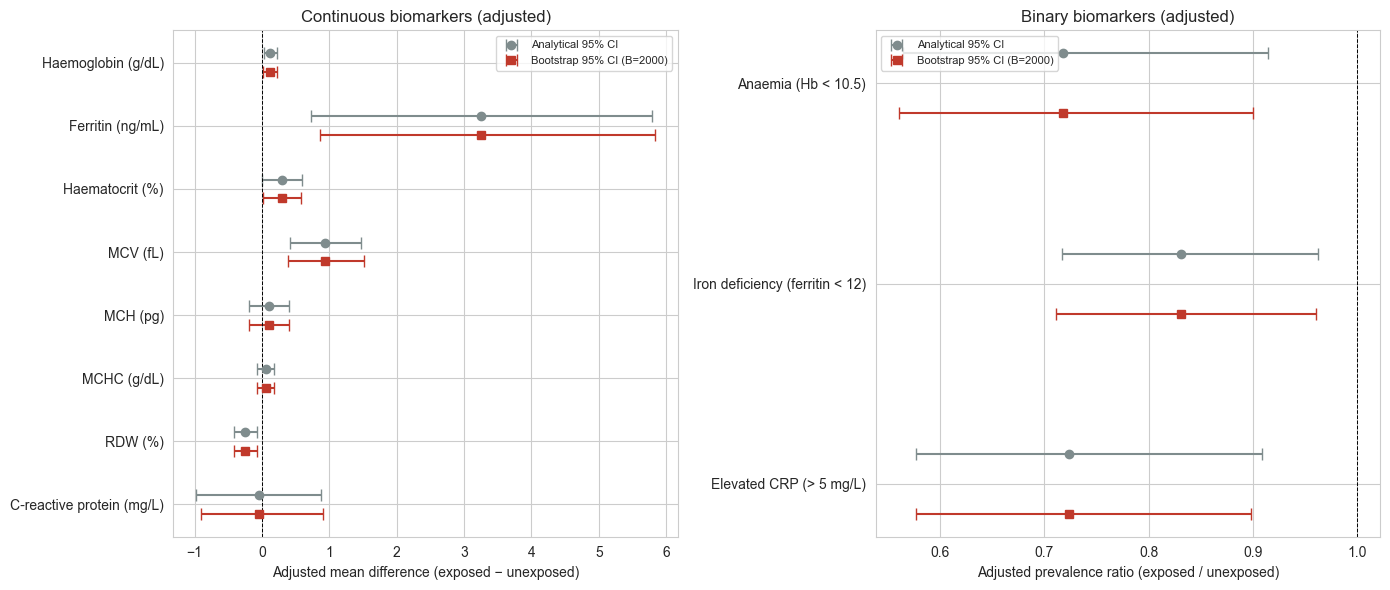

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cont_rows = [r for r in primary_rows if r['Measure'] == 'beta']
labels = [r['Outcome'] for r in cont_rows]
vars_ = [label_to_var[l] for l in labels]
y = np.arange(len(labels))
ests = [r['Estimate'] for r in cont_rows]
lo_a = [r['CI_lo_anal'] for r in cont_rows]
hi_a = [r['CI_hi_anal'] for r in cont_rows]
lo_b = [boot_results[v]['CI_lo_boot'] if boot_results.get(v) else np.nan for v in vars_]
hi_b = [boot_results[v]['CI_hi_boot'] if boot_results.get(v) else np.nan for v in vars_]

ax = axes[0]
ax.errorbar(ests, y - 0.15, xerr=[np.array(ests)-np.array(lo_a), np.array(hi_a)-np.array(ests)], fmt='o', color='#7f8c8d', capsize=4, label='Analytical 95% CI')
ax.errorbar(ests, y + 0.15, xerr=[np.array(ests)-np.array(lo_b), np.array(hi_b)-np.array(ests)], fmt='s', color='#c0392b', capsize=4, label='Bootstrap 95% CI (B=2000)')
ax.axvline(0, color='black', lw=0.7, linestyle='--')
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel('Adjusted mean difference (exposed − unexposed)')
ax.set_title('Continuous biomarkers (adjusted)')
ax.invert_yaxis()
ax.legend(loc='best', fontsize=8)

bin_rows = [r for r in primary_rows if r['Measure'] == 'PR']
labels_b = [r['Outcome'] for r in bin_rows]
vars_b = [label_to_var[l] for l in labels_b]
y2 = np.arange(len(labels_b))
prs = [r['Estimate'] for r in bin_rows]
lo_a2 = [r['CI_lo_anal'] for r in bin_rows]
hi_a2 = [r['CI_hi_anal'] for r in bin_rows]
lo_b2 = [boot_results[v]['CI_lo_boot'] if boot_results.get(v) else np.nan for v in vars_b]
hi_b2 = [boot_results[v]['CI_hi_boot'] if boot_results.get(v) else np.nan for v in vars_b]

ax = axes[1]
ax.errorbar(prs, y2 - 0.15, xerr=[np.array(prs)-np.array(lo_a2), np.array(hi_a2)-np.array(prs)], fmt='o', color='#7f8c8d', capsize=4, label='Analytical 95% CI')
ax.errorbar(prs, y2 + 0.15, xerr=[np.array(prs)-np.array(lo_b2), np.array(hi_b2)-np.array(prs)], fmt='s', color='#c0392b', capsize=4, label='Bootstrap 95% CI (B=2000)')
ax.axvline(1, color='black', lw=0.7, linestyle='--')
ax.set_yticks(y2); ax.set_yticklabels(labels_b)
ax.set_xlabel('Adjusted prevalence ratio (exposed / unexposed)')
ax.set_title('Binary biomarkers (adjusted)')
ax.invert_yaxis()
ax.legend(loc='best', fontsize=8)

fig.tight_layout()
plt.show()

## 8. Sensitivity analysis — iron-only versus no-supplement

Restricts the analysis to two clean groups: infants who received iron alone in the previous six months (without any other co-supplementation) and infants who received no supplement of any kind. This isolates the iron-specific component of the exposure from the broader supplementation pattern documented in Stage 1.

Sample sizes are smaller, so bootstrap CIs are wider.

In [9]:
df_iron_only_subset = df[(df['iron_only'] == 1) | (df['no_supplement'] == 1)].copy()
df_iron_only_subset['_iron_only_vs_none'] = df_iron_only_subset['iron_only'].astype(int)
n_iron_only = int((df_iron_only_subset['_iron_only_vs_none'] == 1).sum())
n_no_supp = int((df_iron_only_subset['_iron_only_vs_none'] == 0).sum())
print(f'Sensitivity sample: iron-only n = {n_iron_only}, no-supplement n = {n_no_supp}')

df_iron_only_imputed = mice_impute_covariates(df_iron_only_subset, random_state=42)

iron_only_rows = []
for outcome in PRIMARY_CONTINUOUS + SECONDARY_CONTINUOUS:
    m = fit_continuous(df_iron_only_imputed, outcome, exposure='_iron_only_vs_none')
    if m is None:
        continue
    coef = float(m.params['_iron_only_vs_none']); se = float(m.bse['_iron_only_vs_none']); p = float(m.pvalues['_iron_only_vs_none'])
    iron_only_rows.append({'Outcome': OUTCOME_LABELS[outcome], 'Measure': 'beta',
                            'Estimate': coef, 'CI_lo_anal': coef-Z95*se, 'CI_hi_anal': coef+Z95*se,
                            'p_anal': p, 'N': int(m.nobs), '_var': outcome})
for outcome in BINARY_OUTCOMES:
    m = fit_binary(df_iron_only_imputed, outcome, exposure='_iron_only_vs_none')
    if m is None:
        continue
    coef = float(m.params['_iron_only_vs_none']); se = float(m.bse['_iron_only_vs_none']); p = float(m.pvalues['_iron_only_vs_none'])
    iron_only_rows.append({'Outcome': OUTCOME_LABELS[outcome], 'Measure': 'PR',
                            'Estimate': float(np.exp(coef)), 'CI_lo_anal': float(np.exp(coef-Z95*se)), 'CI_hi_anal': float(np.exp(coef+Z95*se)),
                            'p_anal': p, 'N': int(m.nobs), '_var': outcome})
iron_only_df = pd.DataFrame(iron_only_rows)
iron_only_df

Sensitivity sample: iron-only n = 353, no-supplement n = 1637


,Outcome,Measure,Estimate,CI_lo_anal,CI_hi_anal,p_anal,N,_var
0,Haemoglobin (g/dL),beta,0.0961,-0.0746,0.2668,0.2699,1095,hb
1,Ferritin (ng/mL),beta,4.1310,-1.2301,9.4922,0.1310,1066,ferritin
2,Haematocrit (%),beta,0.1745,-0.3257,0.6748,0.4941,1095,haematocrit
3,MCV (fL),beta,0.9476,0.0184,1.8768,0.0456,1095,mcv
4,MCH (pg),beta,-0.0900,-0.5708,0.3908,0.7136,1095,mch
5,MCHC (g/dL),beta,0.1323,-0.0733,0.3378,0.2073,1095,mchc
6,RDW (%),beta,-0.2422,-0.5278,0.0434,0.0964,1093,rdw
7,C-reactive protein (mg/L),beta,-0.4894,-2.1522,1.1734,0.5640,1078,crp
8,Anaemia (Hb < 10.5),PR,0.5649,0.3323,0.9603,0.0349,1095,anaemia
9,Iron deficiency (ferritin < 12),PR,0.9018,0.6950,1.1703,0.4371,1066,iron_deficiency


In [10]:
iron_only_boot = {}
t_start = time.time()
for outcome, kind in all_outcomes:
    t0 = time.time()
    coefs = outer_bootstrap_iron(df_iron_only_subset, outcome, kind, B=B, exposure='_iron_only_vs_none', seed=43)
    if len(coefs) == 0:
        iron_only_boot[outcome] = None; continue
    if kind == 'binary':
        _bprs = np.exp(coefs)
        iron_only_boot[outcome] = {
            'CI_lo_boot': float(np.percentile(_bprs, 2.5)), 'CI_hi_boot': float(np.percentile(_bprs, 97.5)),
            'p_boot': boot_pvalue(coefs, 0.0),
        }
    else:
        iron_only_boot[outcome] = {
            'CI_lo_boot': float(np.percentile(coefs, 2.5)), 'CI_hi_boot': float(np.percentile(coefs, 97.5)),
            'p_boot': boot_pvalue(coefs, 0.0),
        }
    print(f'  iron-only {outcome:20s}  {len(coefs)} reps  {time.time()-t0:5.1f}s  p_boot={iron_only_boot[outcome]["p_boot"]:.4f}')
print(f'\nIron-only sensitivity bootstrap time: {(time.time()-t_start)/60:.1f} min')

  iron-only hb                    2000 reps  102.2s  p_boot=0.2710
  iron-only ferritin              2000 reps  101.6s  p_boot=0.1060
  iron-only haematocrit           2000 reps  102.5s  p_boot=0.4990
  iron-only mcv                   2000 reps  102.1s  p_boot=0.0530
  iron-only mch                   2000 reps  102.1s  p_boot=0.7430
  iron-only mchc                  2000 reps  102.2s  p_boot=0.2160
  iron-only rdw                   2000 reps  102.4s  p_boot=0.1190
  iron-only crp                   2000 reps  102.3s  p_boot=0.5580
  iron-only anaemia               2000 reps  108.2s  p_boot=0.0110
  iron-only iron_deficiency       2000 reps  107.0s  p_boot=0.4200
  iron-only crp_elevated          2000 reps  112.4s  p_boot=0.0190

Iron-only sensitivity bootstrap time: 19.1 min


In [11]:
iron_only_combined = []
for r in iron_only_rows:
    var = r['_var']
    boot = iron_only_boot.get(var)
    iron_only_combined.append({
        'Outcome': r['Outcome'], 'Measure': r['Measure'], 'Estimate': r['Estimate'],
        'CI 95% (analytical)': f"[{r['CI_lo_anal']:.4f}, {r['CI_hi_anal']:.4f}]",
        'p (analytical)': r['p_anal'],
        'CI 95% (bootstrap)': f"[{boot['CI_lo_boot']:.4f}, {boot['CI_hi_boot']:.4f}]" if boot else '—',
        'p (bootstrap)': boot['p_boot'] if boot else np.nan,
        'N': r['N'],
    })
iron_only_table = pd.DataFrame(iron_only_combined)
iron_only_table

,Outcome,Measure,Estimate,CI 95% (analytical),p (analytical),CI 95% (bootstrap),p (bootstrap),N
0,Haemoglobin (g/dL),beta,0.0961,"[-0.0746, 0.2668]",0.2699,"[-0.0783, 0.2560]",0.2710,1095
1,Ferritin (ng/mL),beta,4.1310,"[-1.2301, 9.4922]",0.1310,"[-0.6522, 9.7877]",0.1060,1066
2,Haematocrit (%),beta,0.1745,"[-0.3257, 0.6748]",0.4941,"[-0.3370, 0.6661]",0.4990,1095
3,MCV (fL),beta,0.9476,"[0.0184, 1.8768]",0.0456,"[-0.0038, 1.9066]",0.0530,1095
4,MCH (pg),beta,-0.0900,"[-0.5708, 0.3908]",0.7136,"[-0.6035, 0.3848]",0.7430,1095
5,MCHC (g/dL),beta,0.1323,"[-0.0733, 0.3378]",0.2073,"[-0.0741, 0.3349]",0.2160,1095
6,RDW (%),beta,-0.2422,"[-0.5278, 0.0434]",0.0964,"[-0.5269, 0.0631]",0.1190,1093
7,C-reactive protein (mg/L),beta,-0.4894,"[-2.1522, 1.1734]",0.5640,"[-2.1090, 1.1830]",0.5580,1078
8,Anaemia (Hb < 10.5),PR,0.5649,"[0.3323, 0.9603]",0.0349,"[0.2866, 0.9017]",0.0110,1095
9,Iron deficiency (ferritin < 12),PR,0.9018,"[0.6950, 1.1703]",0.4371,"[0.6805, 1.1551]",0.4200,1066


## 8b. Sensitivity analysis — inverse-probability-of-censoring weighting (IPCW)

Approximately 40% of the eligible infants did not complete the ENANI-2019 blood-collection protocol, so the primary adjusted estimates characterise the subgroup with available biomarker measurements. To assess robustness to outcome-missingness mechanisms, every adjusted model is re-fit with stabilised IPCW weights.

The censoring (response) indicator is R = 1 if the biomarker was measured, 0 otherwise. The weight for each respondent is

w_i = P(R = 1) / P(R_i = 1 | X_i, A_i)

where the denominator is the predicted probability from a logistic regression of R on the iron exposure A and the 26 confounders X (using the MICE-imputed covariate matrix from Section 4). Stabilised weights have mean ≈ 1 over respondents and reduce variance relative to unstabilised weights. The IPCW outcome model is the same OLS (continuous) or modified Poisson (binary) specification as the primary analysis, fit on respondents only with the IPCW weights and HC1 robust standard errors. Concordance between primary and IPCW estimates supports a missing-at-random response mechanism conditional on the measured covariates.


In [12]:
def fit_ipcw(df_in, outcome, kind, exposure='iron_any'):
    df_local = df_in.copy()
    df_local['_R'] = df_local[outcome].notna().astype(int)
    rhs = exposure + ' + ' + ' + '.join(CONFOUNDERS)
    p_R = float(df_local['_R'].mean())
    try:
        m_R = smf.logit(f'_R ~ {rhs}', data=df_local).fit(disp=False, maxiter=200)
    except Exception:
        return None
    df_local['_p_R'] = m_R.predict(df_local)
    df_resp = df_local[df_local['_R'] == 1].copy()
    df_resp['_ipcw'] = p_R / df_resp['_p_R']
    if kind == 'continuous':
        m_Y = smf.wls(f'{outcome} ~ {rhs}', data=df_resp, weights=df_resp['_ipcw']).fit(cov_type='HC1')
    else:
        df_resp[outcome] = df_resp[outcome].astype(int)
        m_Y = smf.glm(
            f'{outcome} ~ {rhs}', data=df_resp,
            family=sm.families.Poisson(), freq_weights=df_resp['_ipcw'].values,
        ).fit(cov_type='HC1', disp=False)
    return {
        'model': m_Y,
        'weight_mean': float(df_resp['_ipcw'].mean()),
        'weight_min': float(df_resp['_ipcw'].min()),
        'weight_max': float(df_resp['_ipcw'].max()),
        'response_rate': p_R,
        'n_resp': int((df_local['_R'] == 1).sum()),
    }

ipcw_rows = []
for outcome, kind in all_outcomes:
    res = fit_ipcw(df_imputed, outcome, kind)
    if res is None:
        continue
    m = res['model']
    coef = float(m.params['iron_any'])
    se = float(m.bse['iron_any'])
    p = float(m.pvalues['iron_any'])
    if kind == 'continuous':
        est = coef
        ci_lo, ci_hi = coef - Z95 * se, coef + Z95 * se
        measure = 'beta'
    else:
        est = float(np.exp(coef))
        ci_lo, ci_hi = float(np.exp(coef - Z95 * se)), float(np.exp(coef + Z95 * se))
        measure = 'PR'
    ipcw_rows.append({
        'Outcome': OUTCOME_LABELS[outcome],
        'Measure': measure,
        'IPCW estimate': est,
        'CI 95% (analytical)': f'[{ci_lo:.4f}, {ci_hi:.4f}]',
        'p (analytical)': p,
        'Response rate': res['response_rate'],
        'Mean weight': res['weight_mean'],
        'Min weight': res['weight_min'],
        'Max weight': res['weight_max'],
        'N respondents': res['n_resp'],
        '_var': outcome,
    })

primary_lookup = {label_to_var[r['Outcome']]: r for r in primary_rows}
ipcw_comparison_rows = []
for r in ipcw_rows:
    var = r['_var']
    primary = primary_lookup.get(var)
    ipcw_comparison_rows.append({
        'Outcome': r['Outcome'],
        'Measure': r['Measure'],
        'Primary estimate': primary['Estimate'] if primary else None,
        'Primary CI 95%': f"[{primary['CI_lo_anal']:.4f}, {primary['CI_hi_anal']:.4f}]" if primary else '—',
        'IPCW estimate': r['IPCW estimate'],
        'IPCW CI 95%': r['CI 95% (analytical)'],
        'IPCW p': r['p (analytical)'],
        'Response rate': f"{r['Response rate']*100:.1f}%",
        'Mean weight': f"{r['Mean weight']:.3f}",
        'Weight range': f"[{r['Min weight']:.3f}, {r['Max weight']:.3f}]",
        'N respondents': r['N respondents'],
    })
ipcw_comparison_table = pd.DataFrame(ipcw_comparison_rows)
ipcw_comparison_table


,Outcome,Measure,Primary estimate,Primary CI 95%,IPCW estimate,IPCW CI 95%,IPCW p,Response rate,Mean weight,Weight range,N respondents
0,Haemoglobin (g/dL),beta,0.1242,"[0.0247, 0.2238]",0.1165,"[0.0140, 0.2191]",0.0260,60.6%,1.000,"[0.683, 1.964]",2788
1,Ferritin (ng/mL),beta,3.2564,"[0.7285, 5.7844]",3.1944,"[0.7552, 5.6336]",0.0103,59.3%,0.999,"[0.705, 1.983]",2728
2,Haematocrit (%),beta,0.2994,"[0.0079, 0.5908]",0.3097,"[0.0086, 0.6107]",0.0438,60.6%,1.000,"[0.683, 1.964]",2788
3,MCV (fL),beta,0.9430,"[0.4157, 1.4704]",0.9481,"[0.4009, 1.4953]",0.0007,60.6%,1.000,"[0.683, 1.964]",2788
4,MCH (pg),beta,0.1066,"[-0.1867, 0.4000]",0.0495,"[-0.2678, 0.3667]",0.7598,60.6%,1.000,"[0.683, 1.964]",2788
5,MCHC (g/dL),beta,0.0557,"[-0.0664, 0.1778]",0.0257,"[-0.0926, 0.1439]",0.6707,60.6%,1.000,"[0.683, 1.964]",2788
6,RDW (%),beta,-0.2442,"[-0.4114, -0.0769]",-0.2536,"[-0.4205, -0.0866]",0.0029,60.5%,1.000,"[0.682, 1.944]",2785
7,C-reactive protein (mg/L),beta,-0.0496,"[-0.9721, 0.8728]",-0.0351,"[-0.9767, 0.9066]",0.9418,59.9%,1.000,"[0.701, 2.140]",2756
8,Anaemia (Hb < 10.5),PR,0.7181,"[0.5638, 0.9145]",0.7253,"[0.5678, 0.9265]",0.0101,60.6%,1.000,"[0.683, 1.964]",2788
9,Iron deficiency (ferritin < 12),PR,0.8307,"[0.7168, 0.9626]",0.8434,"[0.7299, 0.9744]",0.0208,59.3%,0.999,"[0.705, 1.983]",2728


## 9. Iron × breastfeeding interaction tests (Pillar 3)

Pre-specified test of whether breastfeeding modifies the iron-supplementation–biomarker association on the four central continuous outcomes (Hb, ferritin, haematocrit, MCV). Model: `outcome ~ iron + breastfed + iron:breastfed + 25 confounders` (breastfeeding moves out of the confounder set into the test set). The interaction coefficient is bootstrapped with B = 2000; null = 0.

In [13]:
INTERACTION_CONFOUNDERS = [c for c in CONFOUNDERS if c != 'breastfed']

def fit_interaction_continuous(df_in, outcome):
    sub = df_in[[outcome, 'iron_any', 'breastfed'] + INTERACTION_CONFOUNDERS].dropna(subset=[outcome, 'iron_any', 'breastfed']).copy()
    sub['iron_x_bf'] = sub['iron_any'] * sub['breastfed']
    if len(sub) < 100:
        return None
    rhs = 'iron_any + breastfed + iron_x_bf + ' + ' + '.join(INTERACTION_CONFOUNDERS)
    return smf.ols(f'{outcome} ~ {rhs}', data=sub).fit(cov_type='HC1')

def boot_interaction(df_in, outcome, B=2000, seed=44):
    rng = np.random.default_rng(seed)
    base = df_in[[outcome, 'iron_any', 'breastfed'] + INTERACTION_CONFOUNDERS].dropna(subset=[outcome, 'iron_any', 'breastfed']).copy()
    n = len(base)
    coefs = []
    for b in range(B):
        idx = rng.integers(0, n, size=n)
        s = base.iloc[idx].reset_index(drop=True)
        s = mice_impute_covariates(s, random_state=int(b))
        s['iron_x_bf'] = s['iron_any'] * s['breastfed']
        rhs = 'iron_any + breastfed + iron_x_bf + ' + ' + '.join(INTERACTION_CONFOUNDERS)
        try:
            m = smf.ols(f'{outcome} ~ {rhs}', data=s).fit()
            coefs.append(float(m.params['iron_x_bf']))
        except Exception:
            continue
    return np.asarray(coefs)

interaction_rows = []
t_start = time.time()
for outcome in PRIMARY_CONTINUOUS:
    t0 = time.time()
    m = fit_interaction_continuous(df_imputed, outcome)
    if m is None:
        continue
    coef = float(m.params['iron_x_bf']); se = float(m.bse['iron_x_bf']); p = float(m.pvalues['iron_x_bf'])
    coefs_b = boot_interaction(df, outcome, B=B, seed=44)
    boot_lo = float(np.percentile(coefs_b, 2.5))
    boot_hi = float(np.percentile(coefs_b, 97.5))
    p_b = boot_pvalue(coefs_b, null=0.0)
    interaction_rows.append({
        'Outcome': OUTCOME_LABELS[outcome],
        'Interaction coef': coef,
        'CI 95% (analytical)': f"[{coef-Z95*se:+.4f}, {coef+Z95*se:+.4f}]",
        'p (analytical)': p,
        'CI 95% (bootstrap)': f"[{boot_lo:+.4f}, {boot_hi:+.4f}]",
        'p (bootstrap)': p_b,
        'N': int(m.nobs),
    })
    print(f'  iron×BF {outcome:15s}  coef={coef:+.4f}  p_anal={p:.4f}  p_boot={p_b:.4f}  {time.time()-t0:5.1f}s')
interaction_table = pd.DataFrame(interaction_rows)
print(f'\nInteraction analyses time: {(time.time()-t_start)/60:.1f} min')
interaction_table

  iron×BF hb               coef=-0.0958  p_anal=0.3383  p_boot=0.3370  139.8s
  iron×BF ferritin         coef=-0.8223  p_anal=0.7296  p_boot=0.7180  138.4s
  iron×BF haematocrit      coef=-0.2756  p_anal=0.3469  p_boot=0.3340  140.8s
  iron×BF mcv              coef=-2.0460  p_anal=0.0001  p_boot=0.0000  141.4s

Interaction analyses time: 9.3 min


,Outcome,Interaction coef,CI 95% (analytical),p (analytical),CI 95% (bootstrap),p (bootstrap),N
0,Haemoglobin (g/dL),-0.0958,"[-0.2920, +0.1003]",0.3383,"[-0.2866, +0.1094]",0.3370,2788
1,Ferritin (ng/mL),-0.8223,"[-5.4855, +3.8410]",0.7296,"[-5.7577, +3.9041]",0.7180,2728
2,Haematocrit (%),-0.2756,"[-0.8498, +0.2986]",0.3469,"[-0.8400, +0.2853]",0.3340,2788
3,MCV (fL),-2.0460,"[-3.0521, -1.0398]",0.0001,"[-3.0766, -1.0299]",0.0000,2788


## 10. Notes on this stage

- Adjusted estimates use 26 confounders with HC1 robust SEs. Two covariates have non-trivial missingness — prenatal visits (~8%) and maternal age (<0.1%) — and are imputed within each bootstrap resample using a Bayesian-ridge IterativeImputer (MICE); all other confounders were complete in the calibrated ENANI-2019 dataset. Outcomes are never imputed.
- The bootstrap p-value is twice the smaller tail probability of the bootstrap coefficient distribution crossing zero.
- BH-FDR is computed only over the seven primary outcomes (Hb, ferritin, haematocrit, MCV, anaemia, iron deficiency, elevated CRP). Secondary outcomes (MCH, MCHC, RDW, CRP continuous) are reported but are not part of the FDR family.
- Iron-only versus no-supplement sensitivity isolates iron from the broader supplementation pattern (vitamin A/D, multivitamin) that confounds the principal exposure.
- IPCW sensitivity (Section 8b) re-fits every adjusted model with stabilised inverse-probability-of-censoring weights to check robustness against the ~40% biomarker missingness; concordance between primary and IPCW estimates supports a missing-at-random response mechanism conditional on the measured covariates.
- Interaction tests are run on the four central continuous outcomes; binary-outcome interactions are deferred to Stage 4 because the interpretation of an interaction term in Poisson regression on a prevalence ratio is more delicate.
- No causal claim is made from any of these estimates.

## 11. Export

In [14]:
# Self-contained export cell.
# Reads tables from CSVs saved by earlier cells, regenerates figures, compiles REPORT.md.
# Earlier cells must have run at least once to populate the tables; after that this cell
# can be re-run alone whenever needed.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

OUTPUT_DIR = Path('./03_adjusted_associations_results')
TABLES_DIR = OUTPUT_DIR / 'tables'
FIGURES_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Save tables from current notebook state if variables exist; otherwise rely on already-saved CSVs.
for var_name, fname in [
    ('missing_table', 'missingness_overview.csv'),
    ('combined', 'primary_adjusted_combined.csv'),
    ('iron_only_table', 'iron_only_sensitivity.csv'),
    ('ipcw_comparison_table', 'ipcw_sensitivity.csv'),
    ('interaction_table', 'iron_x_breastfed_interaction.csv'),
]:
    if var_name in globals():
        kwargs = {} if var_name in ('missing_table',) else {'index': False}
        globals()[var_name].to_csv(TABLES_DIR / fname, **kwargs)

# Now load tables from disk for figure generation. This is the source of truth.
missing_csv = pd.read_csv(TABLES_DIR / 'missingness_overview.csv', index_col=0)
primary_csv = pd.read_csv(TABLES_DIR / 'primary_adjusted_combined.csv')
iron_only_csv = pd.read_csv(TABLES_DIR / 'iron_only_sensitivity.csv')
ipcw_csv = pd.read_csv(TABLES_DIR / 'ipcw_sensitivity.csv') if (TABLES_DIR / 'ipcw_sensitivity.csv').exists() else None
interaction_csv = pd.read_csv(TABLES_DIR / 'iron_x_breastfed_interaction.csv')

def parse_ci(s):
    s = str(s).strip().strip('[]')
    a, b = s.split(',')
    return float(a.strip()), float(b.strip())

cont = primary_csv[primary_csv['Measure'] == 'beta'].copy()
binr = primary_csv[primary_csv['Measure'] == 'PR'].copy()
for sub in (cont, binr):
    sub[['lo_a', 'hi_a']] = pd.DataFrame(sub['CI 95% (analytical)'].apply(parse_ci).tolist(), index=sub.index)
    sub[['lo_b', 'hi_b']] = pd.DataFrame(sub['CI 95% (bootstrap)'].apply(parse_ci).tolist(), index=sub.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
y = np.arange(len(cont))
ax.errorbar(cont['Estimate'], y - 0.15, xerr=[cont['Estimate'] - cont['lo_a'], cont['hi_a'] - cont['Estimate']], fmt='o', color='#7f8c8d', capsize=4, label='Analytical 95% CI')
ax.errorbar(cont['Estimate'], y + 0.15, xerr=[cont['Estimate'] - cont['lo_b'], cont['hi_b'] - cont['Estimate']], fmt='s', color='#c0392b', capsize=4, label='Bootstrap 95% CI (B=2000)')
ax.axvline(0, color='black', lw=0.7, linestyle='--')
ax.set_yticks(y); ax.set_yticklabels(cont['Outcome'])
ax.set_xlabel('Adjusted mean difference (exposed − unexposed)')
ax.set_title('Continuous biomarkers — adjusted')
ax.invert_yaxis(); ax.legend(loc='best', fontsize=8)

ax = axes[1]
y2 = np.arange(len(binr))
ax.errorbar(binr['Estimate'], y2 - 0.15, xerr=[binr['Estimate'] - binr['lo_a'], binr['hi_a'] - binr['Estimate']], fmt='o', color='#7f8c8d', capsize=4, label='Analytical 95% CI')
ax.errorbar(binr['Estimate'], y2 + 0.15, xerr=[binr['Estimate'] - binr['lo_b'], binr['hi_b'] - binr['Estimate']], fmt='s', color='#c0392b', capsize=4, label='Bootstrap 95% CI (B=2000)')
ax.axvline(1, color='black', lw=0.7, linestyle='--')
ax.set_yticks(y2); ax.set_yticklabels(binr['Outcome'])
ax.set_xlabel('Adjusted prevalence ratio (exposed / unexposed)')
ax.set_title('Binary biomarkers — adjusted')
ax.invert_yaxis(); ax.legend(loc='best', fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'forest_adjusted_primary.png', dpi=150, bbox_inches='tight')
plt.close(fig)

io_cont = iron_only_csv[iron_only_csv['Measure'] == 'beta'].copy()
io_bin = iron_only_csv[iron_only_csv['Measure'] == 'PR'].copy()
for sub in (io_cont, io_bin):
    sub[['lo_a', 'hi_a']] = pd.DataFrame(sub['CI 95% (analytical)'].apply(parse_ci).tolist(), index=sub.index)
    sub[['lo_b', 'hi_b']] = pd.DataFrame(sub['CI 95% (bootstrap)'].apply(parse_ci).tolist(), index=sub.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
y = np.arange(len(io_cont))
ax.errorbar(io_cont['Estimate'], y, xerr=[io_cont['Estimate'] - io_cont['lo_b'], io_cont['hi_b'] - io_cont['Estimate']], fmt='s', color='#c0392b', capsize=4)
ax.axvline(0, color='black', lw=0.7, linestyle='--')
ax.set_yticks(y); ax.set_yticklabels(io_cont['Outcome'])
ax.set_xlabel('Mean difference (iron-only − no-supplement), 95% bootstrap CI')
ax.set_title('Iron-only sensitivity — continuous')
ax.invert_yaxis()

ax = axes[1]
y2 = np.arange(len(io_bin))
ax.errorbar(io_bin['Estimate'], y2, xerr=[io_bin['Estimate'] - io_bin['lo_b'], io_bin['hi_b'] - io_bin['Estimate']], fmt='s', color='#c0392b', capsize=4)
ax.axvline(1, color='black', lw=0.7, linestyle='--')
ax.set_yticks(y2); ax.set_yticklabels(io_bin['Outcome'])
ax.set_xlabel('Prevalence ratio (iron-only / no-supplement), 95% bootstrap CI')
ax.set_title('Iron-only sensitivity — binary')
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'forest_iron_only_sensitivity.png', dpi=150, bbox_inches='tight')
plt.close(fig)

ix = interaction_csv.copy()
ix[['lo_a', 'hi_a']] = pd.DataFrame(ix['CI 95% (analytical)'].apply(parse_ci).tolist(), index=ix.index)
ix[['lo_b', 'hi_b']] = pd.DataFrame(ix['CI 95% (bootstrap)'].apply(parse_ci).tolist(), index=ix.index)
fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(ix))
ax.errorbar(ix['Interaction coef'], y, xerr=[ix['Interaction coef'] - ix['lo_b'], ix['hi_b'] - ix['Interaction coef']], fmt='s', color='#c0392b', capsize=4)
ax.axvline(0, color='black', lw=0.7, linestyle='--')
ax.set_yticks(y); ax.set_yticklabels(ix['Outcome'])
ax.set_xlabel('Iron × Breastfeeding interaction coefficient (95% bootstrap CI)')
ax.set_title('Iron × Breastfeeding interaction (Pillar 3 test)')
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'forest_iron_x_breastfeeding.png', dpi=150, bbox_inches='tight')
plt.close(fig)

report = []
report.append('# 03 — Adjusted associations between iron supplementation and haematological / inflammatory biomarkers (B = 2000, MICE)\n')
report.append('**Sample:** Brazilian infants 6–24 mo (ENANI-2019). N = 4,601.\n')
report.append('**Method:** adjusted Poisson (binary) and OLS (continuous) regression with HC1 robust SE; 26 confounders; outer bootstrap B = 2000 with MICE imputation per resample; BH-FDR over seven primary outcomes.\n')
report.append('---\n')
report.append('## Missing data overview\n')
report.append(missing_csv.to_markdown() + '\n')
report.append('## Primary adjusted estimates (analytical + bootstrap)\n')
report.append(primary_csv.to_markdown(index=False) + '\n')
report.append('### Forest plot of primary estimates\n')
report.append('![Adjusted forest plot](figures/forest_adjusted_primary.png)\n')
report.append('## Sensitivity — iron alone versus no supplement\n')
report.append('Restricts to infants exposed to iron alone (no co-supplementation) versus infants who received no supplement at all (n ≈ 1,095). Isolates iron-specific effect from the broader supplementation pattern.\n')
report.append(iron_only_csv.to_markdown(index=False) + '\n')
report.append('![Iron-only sensitivity forest](figures/forest_iron_only_sensitivity.png)\n')
if ipcw_csv is not None:
    report.append('## Sensitivity — inverse-probability-of-censoring weighting (IPCW)\n')
    report.append('Stabilised IPCW weights re-fit every adjusted model on respondents only, weighting by the inverse predicted probability of biomarker measurement (logit of response on iron + 26 confounders). Concordance between primary and IPCW estimates supports a missing-at-random response mechanism conditional on the measured covariates.\n')
    report.append(ipcw_csv.to_markdown(index=False) + '\n')
report.append('## Iron × breastfeeding interaction (continuous outcomes — Pillar 3 test)\n')
report.append('Pre-specified test of whether breastfeeding modifies the iron-supplementation–biomarker association on the four central continuous outcomes.\n')
report.append(interaction_csv.to_markdown(index=False) + '\n')
report.append('![Iron × breastfeeding interaction forest](figures/forest_iron_x_breastfeeding.png)\n')
report.append('---\n')
report.append('## Notes\n')
report.append('- Adjusted estimates use 26 confounders with HC1 robust SEs.\n')
report.append('- MICE (Bayesian-ridge IterativeImputer) imputes covariates with missingness per bootstrap resample; outcomes are never imputed.\n')
report.append('- Bootstrap p-value = 2 × min(tail probability of crossing zero).\n')
report.append('- BH-FDR computed over the seven primary outcomes only.\n')
report.append('- No causal claim is made from these estimates.\n')
(OUTPUT_DIR / 'REPORT.md').write_text('\n'.join(report))

print(f'Outputs written to: {OUTPUT_DIR.resolve()}')
for p in sorted(OUTPUT_DIR.rglob('*')):
    if p.is_file():
        print(f'  {p.relative_to(OUTPUT_DIR)}  ({p.stat().st_size/1024:.1f} KB)')


Outputs written to: /Users/marcelocarvalhoesilva/project/IronBrazil/Analysis/03_adjusted_associations_results
  REPORT.md  (11.9 KB)
  figures/forest_adjusted_primary.png  (90.2 KB)
  figures/forest_iron_only_sensitivity.png  (73.6 KB)
  figures/forest_iron_x_breastfeeding.png  (35.4 KB)
  tables/ipcw_sensitivity.csv  (1.8 KB)
  tables/iron_only_sensitivity.csv  (1.3 KB)
  tables/iron_x_breastfed_interaction.csv  (0.5 KB)
  tables/missingness_overview.csv  (1.1 KB)
  tables/primary_adjusted_combined.csv  (1.4 KB)
